Total time steps: 1000
Fold size (training data): 500.0
Delta between fold starts: 125.0
Train start indices: [  0 125 250 375 500]


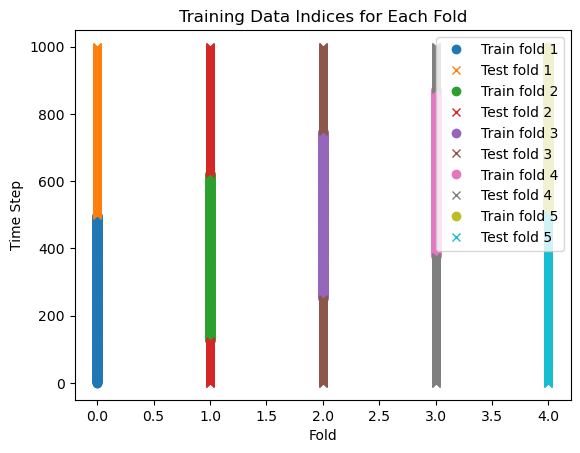

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def cv_split(K: int, r: float, T: int, verbose = False):
    '''
    Make K contiguous splits of the data for cross validation, where each split uses a proportion r of the data for training and the rest for testing. The splits are contiguous in time to preserve temporal structure.

    Parameters:
    K: number of folds
    r: proportion of data to use for training in each fold
    T: total number of time steps in the data

    Returns:
    train_indices: a list of K arrays, where each array contains the indices of the training data for that fold
    test_indices: a list of K arrays, where each array contains the indices of the testing
    '''

    fold_size = np.floor(r * T)
    delta = np.floor((T - fold_size) / (K - 1))
    train_starts = np.arange(0, T - fold_size + delta, delta).astype(int)
    train_indices = [np.arange(start, start + fold_size).astype(int) for start in train_starts]
    test_indices = [np.setdiff1d(np.arange(T), train_idx) for train_idx in train_indices]

    if verbose:
        print(f'Total time steps: {T}')
        print(f'Fold size (training data): {fold_size}')
        print(f'Delta between fold starts: {delta}')
        print(f'Train start indices: {train_starts}')


    return train_indices, test_indices


train_indices, test_indices = cv_split(K=5, r=0.5, T=1000, verbose = True)

plt.figure()
for i in range(5):
    plt.plot(np.ones_like(train_indices[i]) * i, train_indices[i], 'o', label=f'Train fold {i+1}')
    plt.plot(np.ones_like(test_indices[i]) * i, test_indices[i], 'x', label=f'Test fold {i+1}')
plt.xlabel('Fold')
plt.ylabel('Time Step')
plt.title('Training Data Indices for Each Fold')
plt.legend()
plt.show()
